## Path configuration

In [1]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [2]:
import numpy as np
import pandas as pd

# utils
from utils.config import load_config
from utils.data import load_pkl
from utils.metrics import *
from utils.viz import *
from utils.style_transfer import style_transfer

# tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
import shap
from sklearn.linear_model import LogisticRegression

/export/usuarios01/agnavarr/MALDIAlign/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data loading

In [3]:
cfg = load_config()
driams_pkl = cfg["data"]["DRIAMS_REDUCED_PKL"]

In [4]:
driams = load_pkl(driams_pkl)

In [5]:
data, label, meta = driams["data"], driams["label"], pd.DataFrame.from_records(list(driams["meta"]))

In [6]:
# Apply normalization: scale each spectrum to [0, 1]
X_min = data.min(axis=1, keepdims=True)
X_max = data.max(axis=1, keepdims=True)
data_norm = (data - X_min) / (X_max - X_min + 1e-8)

In [7]:
# Filter the data by hospital
filtered_data = {}
for hosp in meta["hospital"].unique():
    idx = np.where(meta["hospital"].values == hosp)[0]
    filtered_data[hosp] = {
        "data": data_norm[idx],
        "label": label[idx],
        "meta": meta.iloc[idx]
    }

In [8]:
# Declare the datasets
dataA, labelA, metaA = filtered_data["DRIAMS_A"]["data"], filtered_data["DRIAMS_A"]["label"], filtered_data["DRIAMS_A"]["meta"]
dataD, labelD, metaD = filtered_data["DRIAMS_D"]["data"], filtered_data["DRIAMS_D"]["label"], filtered_data["DRIAMS_D"]["meta"]

## Style transfer

#### Utils

In [9]:
import torch
from models.deep.MultiVAEPrior import MultiVAE_Bernoulli_SpeciesPrior_Extended

In [10]:
def load_model(model, path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

def encode_latent(model, X, device, batch_size=256):
    model.eval()
    Z = []

    X_tensor = torch.tensor(X, dtype=torch.float32)

    loader = torch.utils.data.DataLoader(
        X_tensor,
        batch_size=batch_size,
        shuffle=False
    )

    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            mu, _ = model.encoder(x)
            Z.append(mu.cpu().numpy())

    return np.vstack(Z)

#### Load MultiDecoder

In [11]:
meta_all = pd.concat([metaA, metaD], ignore_index=True)
data_all = np.vstack([dataA, dataD])
label_all = np.concatenate([labelA,labelD])

In [12]:
vae_path = "experiments/results/vae_multidecoder_prior/20260116_084734/model.pth"

backbone = MultiVAE_Bernoulli_SpeciesPrior_Extended(
    input_dim=dataA.shape[1],
    latent_dim=64,
    num_domains=2,
    n_species=len(np.unique(labelA))
)

vae = load_model(backbone, vae_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Train Logistic Regression to classify domains

In [52]:
X = data_all
y = meta_all["hospital"].values

# Train / Test (hold-out para style transfer)
X_tr, X_test, y_tr, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Train / Val (opcional, para sanity check)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr,
    test_size=0.4,
    stratify=y_tr,
    random_state=42
)

In [53]:
clf_x = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)

clf_x.fit(X_tr, y_tr)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [54]:
val_ba = balanced_accuracy_score(y_val, clf_x.predict(X_val))
print("Domain BA on validation (x):", val_ba)

Domain BA on validation (x): 0.9844793879336031


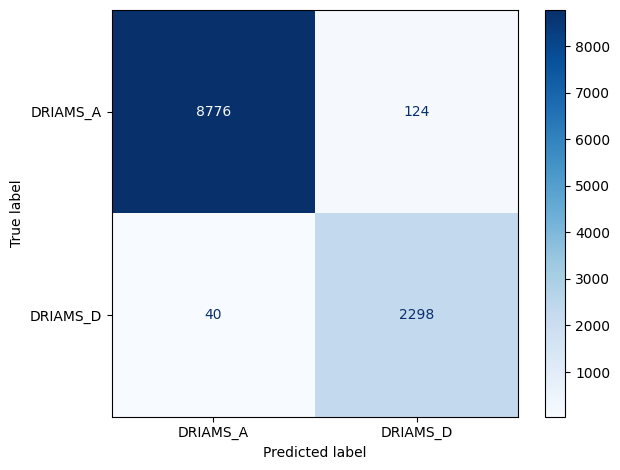

In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true=y_val, y_pred=clf_x.predict(X_val), labels=clf_x.classes_)
disp = ConfusionMatrixDisplay(
    cm, display_labels=clf_x.classes_
)

disp.plot(cmap="Blues")
plt.tight_layout()
plt.show()

#### Transfer A to D

In [58]:
DOMAIN_MAP = {
    "DRIAMS_A": 0,
    "DRIAMS_D": 1,
}

In [59]:
X_testA = X_test[np.where(y_test == "DRIAMS_A")]

In [60]:
X_A_to_D = style_transfer(
    model=vae,
    X=X_testA,
    domain_target_id=DOMAIN_MAP["DRIAMS_D"],
    device=device
)

In [ ]:
y_pred = clf_x.predict(X_A_to_D)

pred_percent = pd.Series(y_pred).value_counts(normalize=True) * 100
print(pred_percent)

DRIAMS_D    0.976268
DRIAMS_A    0.023732
Name: proportion, dtype: float64


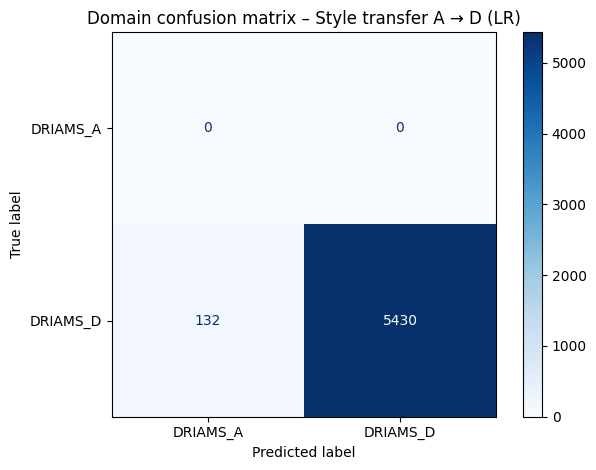

In [ ]:
y_true = np.full(
    shape=len(y_pred),
    fill_value="DRIAMS_D"
)

cm = confusion_matrix(y_true=y_true, y_pred=y_pred, labels=clf_x.classes_)
disp = ConfusionMatrixDisplay(
    cm, display_labels=clf_x.classes_
)

disp.plot(cmap="Blues")
plt.title("Domain confusion matrix – Style transfer A → D (LR)")
plt.tight_layout()
plt.show()

#### Transfer D to A

In [65]:
X_testD = X_test[np.where(y_test == "DRIAMS_D")]

In [66]:
X_D_to_A = style_transfer(
    model=vae,
    X=X_testD,
    domain_target_id=DOMAIN_MAP["DRIAMS_A"],
    device=device
)

In [67]:
y_pred2 = clf_x.predict(X_D_to_A)
pred_percent2 = pd.Series(y_pred2).value_counts(normalize=True) * 100
print(pred_percent2)

DRIAMS_A    97.127223
DRIAMS_D     2.872777
Name: proportion, dtype: float64


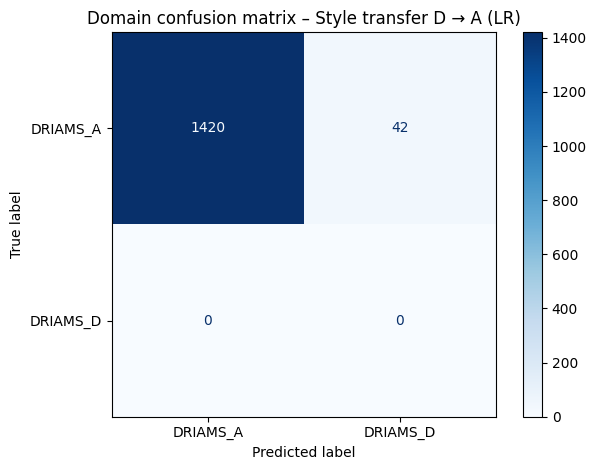

In [72]:
y_true2 = np.full(
    shape=len(y_pred2),
    fill_value="DRIAMS_A"
)

cm = confusion_matrix(y_true=y_true2, y_pred=y_pred2, labels=clf_x.classes_)
disp = ConfusionMatrixDisplay(
    cm, display_labels=clf_x.classes_
)

disp.plot(cmap="Blues")
plt.title("Domain confusion matrix – Style transfer D → A (LR)")
plt.tight_layout()
plt.show()

### Train MLP to classify domains

##### Arch def

In [78]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim

class MLPClassifier(nn.Module):
    def __init__(self, input_dim, n_domains):
        super().__init__()
        self.input_dim = input_dim
        self.n_domains = n_domains

        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),

            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, n_domains)
        )

    def forward(self, x):
        x = self.net(x)
        return x

class MLPClassifier_Extended(MLPClassifier):
    def __init__(self, input_dim, n_domains, epochs, lr, patience):
        super().__init__(input_dim, n_domains)
        self.epochs = epochs
        self.lr = lr
        self.patience = patience

        self.optimizer = optim.Adam(self.parameters(), lr=self.lr)
        self.loss = nn.CrossEntropyLoss()

        self.loss_during_training = []
        self.val_loss_during_training = []

    def trainloop(self, trainloader, validloader, device):
        self.to(device)

        best_val_loss = float("inf")
        patience_counter = 0
        best_state = None

        for epoch in range(self.epochs):
            train_loss, val_loss = 0, 0

            # =======================
            #        TRAIN
            # =======================
            self.train()
            for batch in trainloader:
                x, domain_id = batch
                x, domain_id = x.to(device), domain_id.to(device)

                self.optimizer.zero_grad()
                pred = self.forward(x)
                loss = self.loss(pred, domain_id)
                loss.backward()
                self.optimizer.step()

                train_loss += loss.item()
        
            train_loss /= len(trainloader)

            # =======================
            #      VALIDATION
            # =======================
            self.eval()
            
            with torch.no_grad():
                for batch in validloader:
                    x, domain_id = batch
                    x, domain_id = x.to(device), domain_id.to(device)
                    pred = self.forward(x)
                    loss = self.loss(pred, domain_id)
                    val_loss += loss.item()
            
            val_loss /= len(validloader)

            self.loss_during_training.append(train_loss)
            self.val_loss_during_training.append(val_loss)

            if (epoch + 1) % 10 == 0:
                print(
                    f"Epoch {epoch+1}/{self.epochs} | "
                    f"Train Loss: {train_loss} | Validation Loss: {val_loss}")

            # =======================
            #     EARLY STOPPING
            # =======================
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = copy.deepcopy(self.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
            
            if patience_counter >= self.patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
        
        if best_state is not None:
            self.load_state_dict(best_state)


##### Train

In [79]:
X = data_all
y = meta_all["hospital"].values

In [80]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [81]:
# Train / Test (hold-out para style transfer)
X_tr, X_test, y_tr, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

# Train / Val (opcional, para sanity check)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr,
    test_size=0.4,
    stratify=y_tr,
    random_state=42
)

In [82]:
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_tr, dtype=torch.float32)
y_train_t = torch.tensor(y_tr, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

In [83]:
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset   = TensorDataset(X_test_t, y_test_t)

In [84]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [85]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [29]:
mlp = MLPClassifier_Extended(X_tr.shape[1], len(np.unique(y)), epochs=50, lr=1e-4, patience=20)
mlp.trainloop(train_loader, val_loader, device)

Epoch 10/50 | Train Loss: 0.005548454566561497 | Validation Loss: 0.027507033982477547
Epoch 20/50 | Train Loss: 0.0019994452432208413 | Validation Loss: 0.026846020434711383
Epoch 30/50 | Train Loss: 0.0005313177366932712 | Validation Loss: 0.021392231067538472
Early stopping at epoch 35


In [30]:
def plot_training_curves(train_loss, val_loss, title="MLP training"):
    epochs = range(1, len(train_loss) + 1)

    plt.figure()
    plt.plot(epochs, train_loss, label="Train loss")
    plt.plot(epochs, val_loss, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

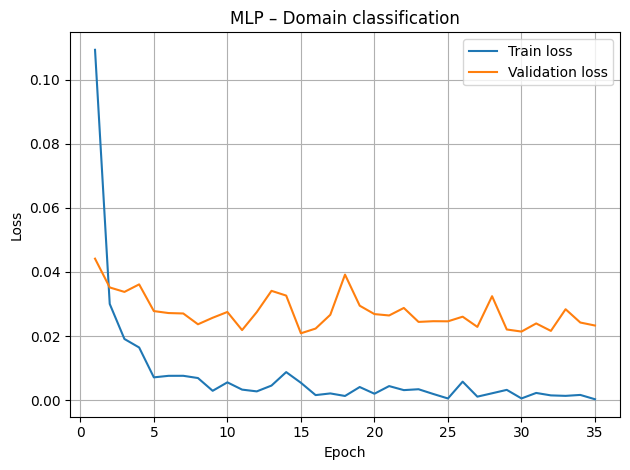

In [31]:
plot_training_curves(
    mlp.loss_during_training,
    mlp.val_loss_during_training,
    title="MLP – Domain classification"
)

##### Test

In [32]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import torch

def evaluate_domain_classifier(model, dataloader, device):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, domain_id in dataloader:
            x = x.to(device)
            domain_id = domain_id.to(device)

            logits = model(x)
            preds = torch.argmax(logits, dim=1)

            y_true.append(domain_id.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    acc = accuracy_score(y_true, y_pred)
    ba  = balanced_accuracy_score(y_true, y_pred)

    return acc, ba, y_true, y_pred

In [38]:
acc_test, ba_test, y_true, y_pred = evaluate_domain_classifier(
    mlp, val_loader, device
)

print(f"MLP domain accuracy (test): {acc_test:.4f}")
print(f"MLP domain balanced accuracy (test): {ba_test:.4f}")

MLP domain accuracy (test): 0.9929
MLP domain balanced accuracy (test): 0.9890


#### Style transfer (A to D)

In [20]:
DOMAIN_MAP = {
    "DRIAMS_A": 0,
    "DRIAMS_D": 1,
}

In [75]:
le.classes_

array(['DRIAMS_A', 'DRIAMS_D'], dtype=object)

In [87]:
label_A = le.transform(["DRIAMS_A"])[0]
label_D = le.transform(["DRIAMS_D"])[0]

In [88]:
# Encode domain labels
X_testA = X_test[y_test == label_A]
X_A_to_D = style_transfer(
    model=vae,
    X=X_testA,
    domain_target_id=DOMAIN_MAP["DRIAMS_D"],
    device=device
)

# Predict with MLP
mlp.eval()
with torch.no_grad():
    X_tensor = torch.tensor(X_A_to_D, dtype=torch.float32).to(device)
    logits = mlp(X_tensor)
    preds = torch.argmax(logits, dim=1).cpu().numpy()

pred_percent = pd.Series(le.inverse_transform(preds)).value_counts(normalize=True) * 100
print(pred_percent)


DRIAMS_D    97.986336
DRIAMS_A     2.013664
Name: proportion, dtype: float64


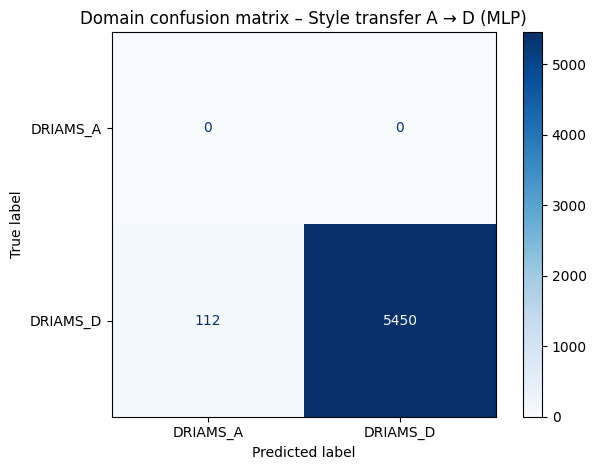

In [89]:
# ground truth: todo es D
y_true = np.full(len(preds), label_D)

cm = confusion_matrix(
    y_true=y_true,
    y_pred=preds,
    labels=[label_A, label_D]
)

disp = ConfusionMatrixDisplay(
    cm,
    display_labels=le.inverse_transform([label_A, label_D])
)

disp.plot(cmap="Blues")
plt.title("Domain confusion matrix – Style transfer A → D (MLP)")
plt.tight_layout()
plt.show()

#### Style transfer (D to A)

In [90]:
X_testD = X_test[np.where(y_test == label_D)]

X_D_to_A = style_transfer(
    model=vae,
    X=X_testD,
    domain_target_id=DOMAIN_MAP["DRIAMS_A"],
    device=device
)

with torch.no_grad():
    X_tensor = torch.tensor(X_D_to_A, dtype=torch.float32).to(device)
    logits = mlp(X_tensor)
    preds = torch.argmax(logits, dim=1).cpu().numpy()

pred_percent = pd.Series(le.inverse_transform(preds)).value_counts(normalize=True) * 100
print(pred_percent)

DRIAMS_A    99.316005
DRIAMS_D     0.683995
Name: proportion, dtype: float64


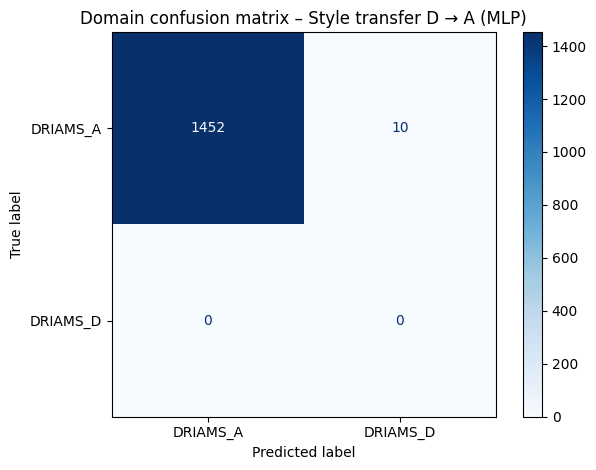

In [91]:
# ground truth: todo es A
y_true = np.full(len(preds), label_A)

cm = confusion_matrix(
    y_true=y_true,
    y_pred=preds,
    labels=[label_A, label_D]
)

disp = ConfusionMatrixDisplay(
    cm,
    display_labels=le.inverse_transform([label_A, label_D])
)

disp.plot(cmap="Blues")
plt.title("Domain confusion matrix – Style transfer D → A (MLP)")
plt.tight_layout()
plt.show()

## Another possible example (RF on DRIAMS-A)

In [13]:
from sklearn.ensemble import RandomForestClassifier

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    dataA,
    labelA,
    test_size=0.2,
    stratify=labelA,
    shuffle=True,
    random_state=42
)

X_trainD, X_testD, y_trainD, y_testD = train_test_split(
    dataD,
    labelD,
    stratify=labelD,
    test_size=0.2,
    shuffle=True,
    random_state=42
)

### Train

In [15]:
rf_driamsA = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)
rf_driamsA.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
rf_driamsD = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)
rf_driamsD.fit(X_trainD, y_trainD)

,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Test


===== Metrics =====
Domain: DRIAMS-A (train), DRIAMS-A (test)
Balanced Accuracy: 0.9982
F1 Macro: 0.9986
Recall Macro: 0.9982
Specificity Macro: 0.9997



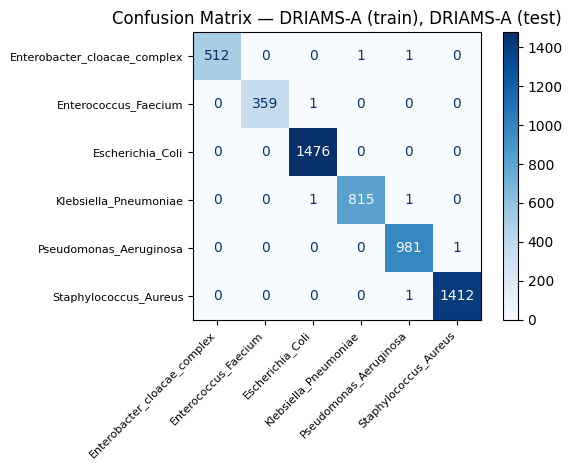


===== Metrics =====
Domain: DRIAMS-A (train), DRIAMS-D (test)
Balanced Accuracy: 0.9230
F1 Macro: 0.9117
Recall Macro: 0.9230
Specificity Macro: 0.9818



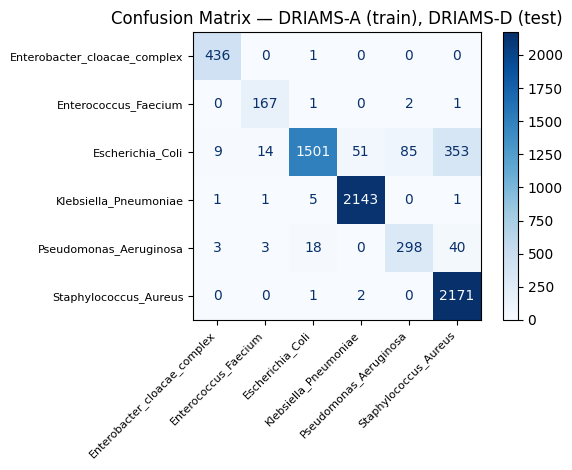


===== Metrics =====
Domain: DRIAMS-D (train), DRIAMS-D (test)
Balanced Accuracy: 0.9890
F1 Macro: 0.9930
Recall Macro: 0.9890
Specificity Macro: 0.9990



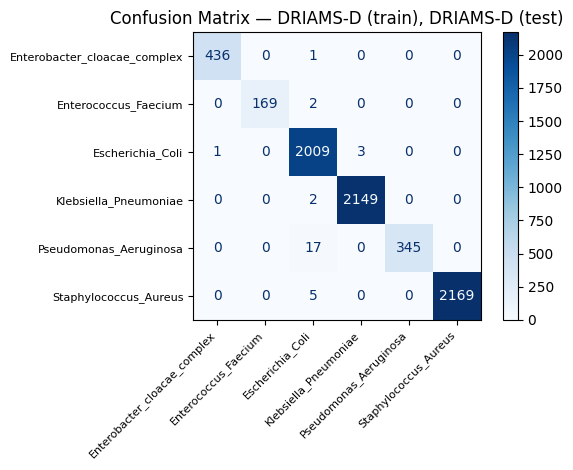

In [19]:
metricsA = metrics_report(X_test, y_test, rf_driamsA, "DRIAMS-A (train), DRIAMS-A (test)")
metricsAD = metrics_report(dataD, labelD, rf_driamsA, "DRIAMS-A (train), DRIAMS-D (test)")
metricsDD = metrics_report(dataD, labelD, rf_driamsD, "DRIAMS-D (train), DRIAMS-D (test)")


print_metrics(metricsA)
print_metrics(metricsAD)
print_metrics(metricsDD)

### Transfer D to A and check performance

In [21]:
X_D_to_A = style_transfer(
    model=vae,
    X=dataD,
    domain_target_id=DOMAIN_MAP["DRIAMS_A"],
    device=device
)


===== Metrics =====
Domain: D to A
Balanced Accuracy: 0.9488
F1 Macro: 0.9290
Recall Macro: 0.9488
Specificity Macro: 0.9883



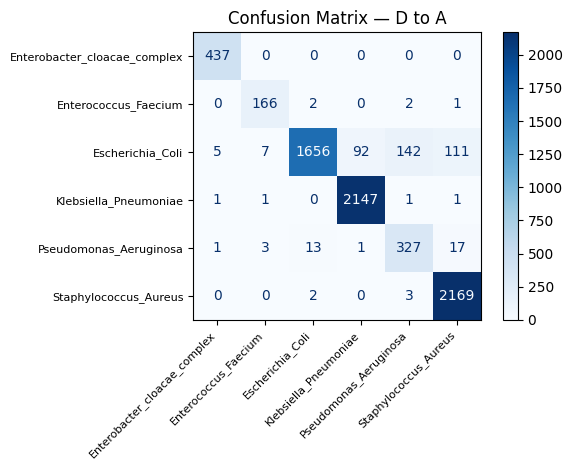

In [22]:
metricsD_to_A = metrics_report(X_D_to_A, labelD, rf_driamsA, "D to A")
print_metrics(metricsD_to_A)

### Feature Importance

In [42]:
K = 20

feature_imp_driamsA = rf_driamsA.feature_importances_
feature_imp_driamsD = rf_driamsD.feature_importances_

ordered_featuresA = {}
ordered_featuresD = {}

idx_orderedA = np.argsort(feature_imp_driamsA)[::-1][:K]
for idx in idx_orderedA:
    feature_name = f"Feature {idx}"
    ordered_featuresA[feature_name] = feature_imp_driamsA[idx]

idx_orderedD = np.argsort(feature_imp_driamsD)[::-1][:K]
for idx in idx_orderedD:
    feature_name = f"Feature {idx}"
    ordered_featuresD[feature_name] = feature_imp_driamsD[idx]

In [55]:
overlap = set(idx_orderedA) & set(idx_orderedD)
jaccard = len(overlap) / len(set(idx_orderedA) | set(idx_orderedD))

print(f"Overlap (top-{K}): {len(overlap)}")
print(f"Jaccard index: {jaccard:.3f}")


Overlap (top-20): 7
Jaccard index: 0.212


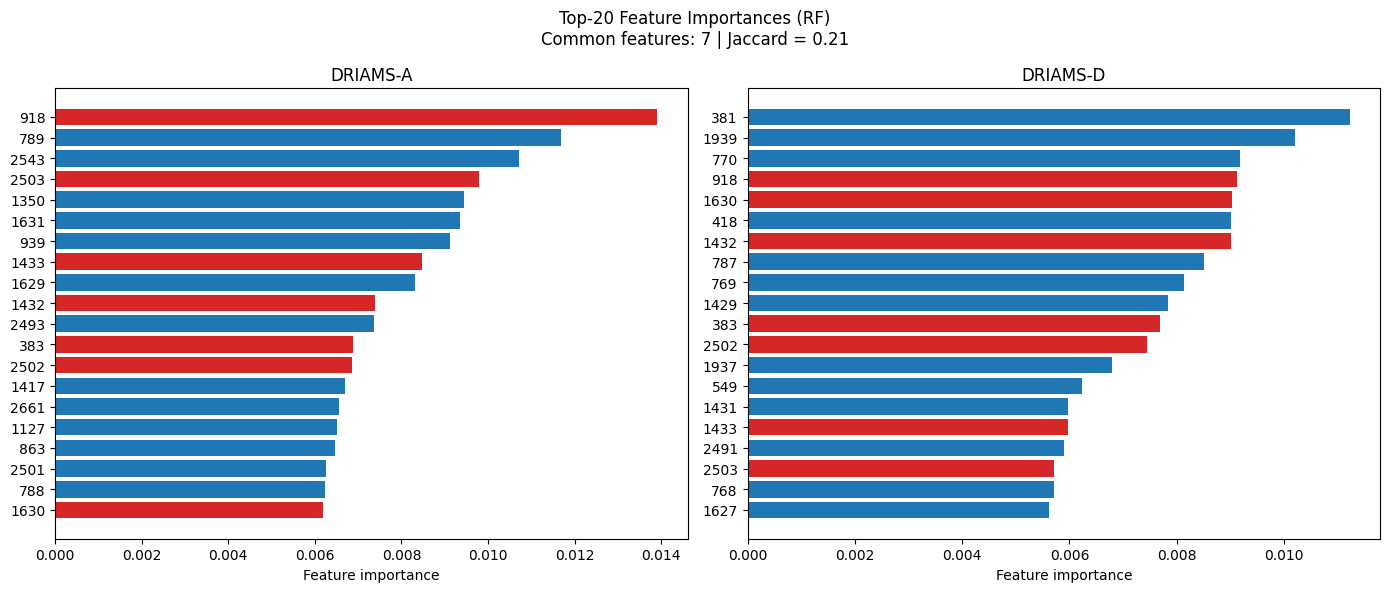

In [ ]:
labels_A = [str(i) for i in idx_orderedA[::-1]]
values_A = feature_imp_driamsA[idx_orderedA][::-1]

colors_A = [
    "tab:red" if i in overlap else "tab:blue"
    for i in idx_orderedA[::-1]
]

labels_D = [str(i) for i in idx_orderedD[::-1]]
values_D = feature_imp_driamsD[idx_orderedD][::-1]

colors_D = [
    "tab:red" if i in overlap else "tab:blue"
    for i in idx_orderedD[::-1]
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# DRIAMS-A
axes[0].barh(labels_A, values_A, color=colors_A)
axes[0].set_title("DRIAMS-A")
axes[0].set_xlabel("Feature importance")

# DRIAMS-D
axes[1].barh(labels_D, values_D, color=colors_D)
axes[1].set_title("DRIAMS-D")
axes[1].set_xlabel("Feature importance")

plt.suptitle(
    f"Top-{K} Feature Importances (RF)\n"
    f"Common features: {len(overlap)} | Jaccard = {jaccard:.2f}"
)
plt.tight_layout()
plt.show()

### SHAP

In [63]:
explainer = shap.TreeExplainer(rf_driamsA)
shap_A = explainer.shap_values(X_test)
shap_D = explainer.shap_values(dataD)
shap_D_to_A = explainer.shap_values(X_D_to_A)

In [64]:
mean_shap = {}
for species in range(len(np.unique(y_test))):
    meanA = np.abs(shap_A[:, :, species]).mean(axis=0)
    meanD = np.abs(shap_D[:, :, species]).mean(axis=0)
    meanD_to_A = np.abs(shap_D_to_A[:, :, species]).mean(axis=0)

    mean_shap[species] = {
        "A": meanA,
        "D": meanD,
        "D_to_A": meanD_to_A
    }

In [65]:
# Ahora tenemos por cada especie, la importancia media de cada feature para las muestras de testA, testD y DtoA
# Lo que queremos hacer ahora es ordenarlas
mean_shap_sorted = {}
for species, d in mean_shap.items():
    mean_shap_sorted[species] = {}
    for key, vec in d.items():
        # argsort returns the indexes that would sort an array
        idx = np.argsort(vec)[::-1]

        # meter, para cada especie y media de importancia, el valor y la posicion del orden
        mean_shap_sorted[species][key] = {
            "values": vec[idx],
            "indices": idx
        }

In [74]:
# Ahora lo que tenemos que hacer es seleccionar un top-K y plotear y calcular intersección
K = 30
results = {}
for species in mean_shap_sorted:
    # Use sets because val in my_set is an O(1) lookup, whereas val in my_list is O(N)
    topA = set(mean_shap_sorted[species]["A"]["indices"][:K])
    topD = set(mean_shap_sorted[species]["D"]["indices"][:K])
    topDA = set(mean_shap_sorted[species]["D_to_A"]["indices"][:K])

    results[species] = {
        "overlap_A_D": len(topA & topD),
        "overlap_A_D_to_A": len(topA & topDA),
        "jaccard_A_D": len(topA & topD) / len(topA | topD),
        "jaccard_A_D_to_A": len(topA & topDA) / len(topA | topDA),
    }
    

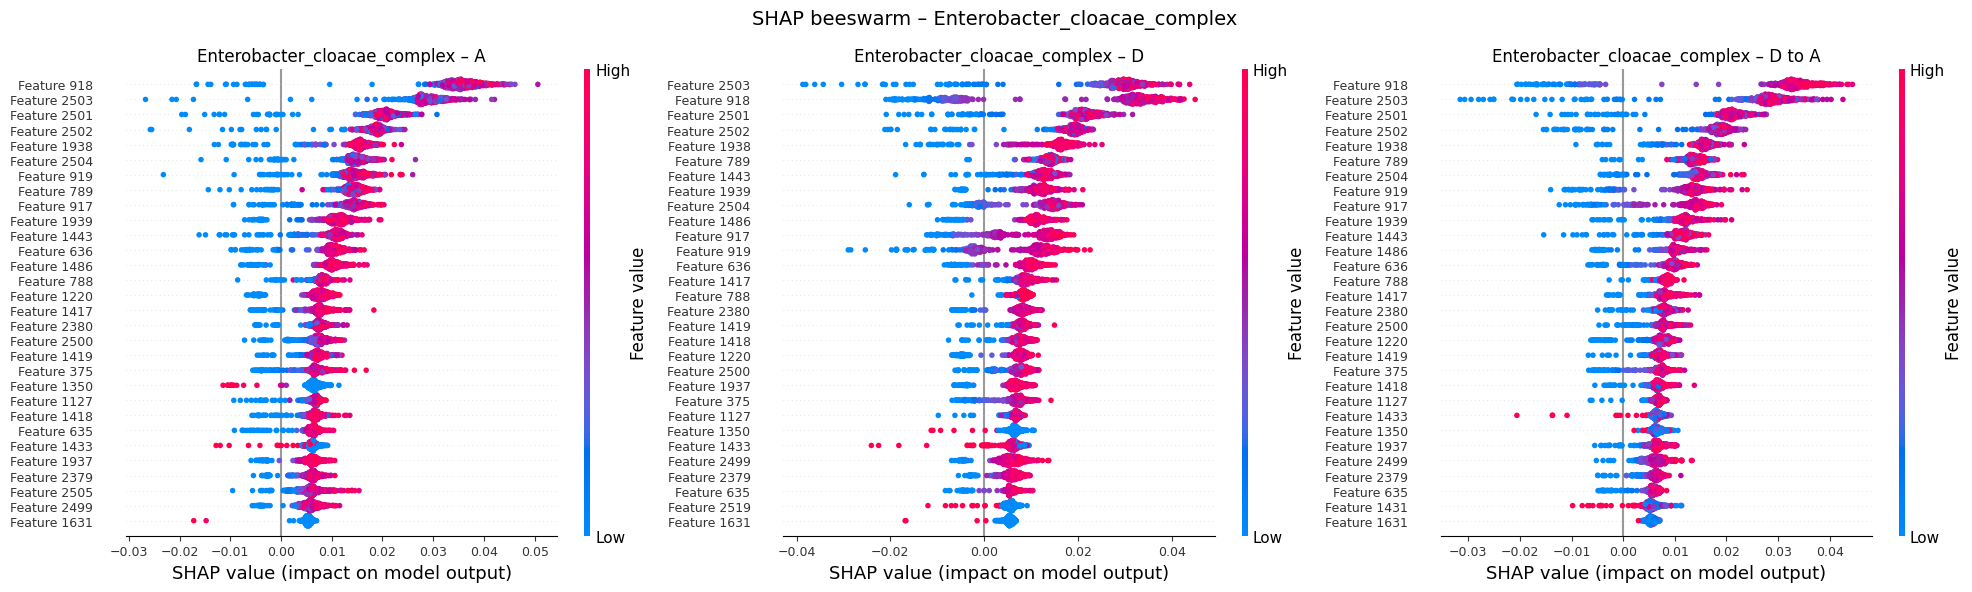

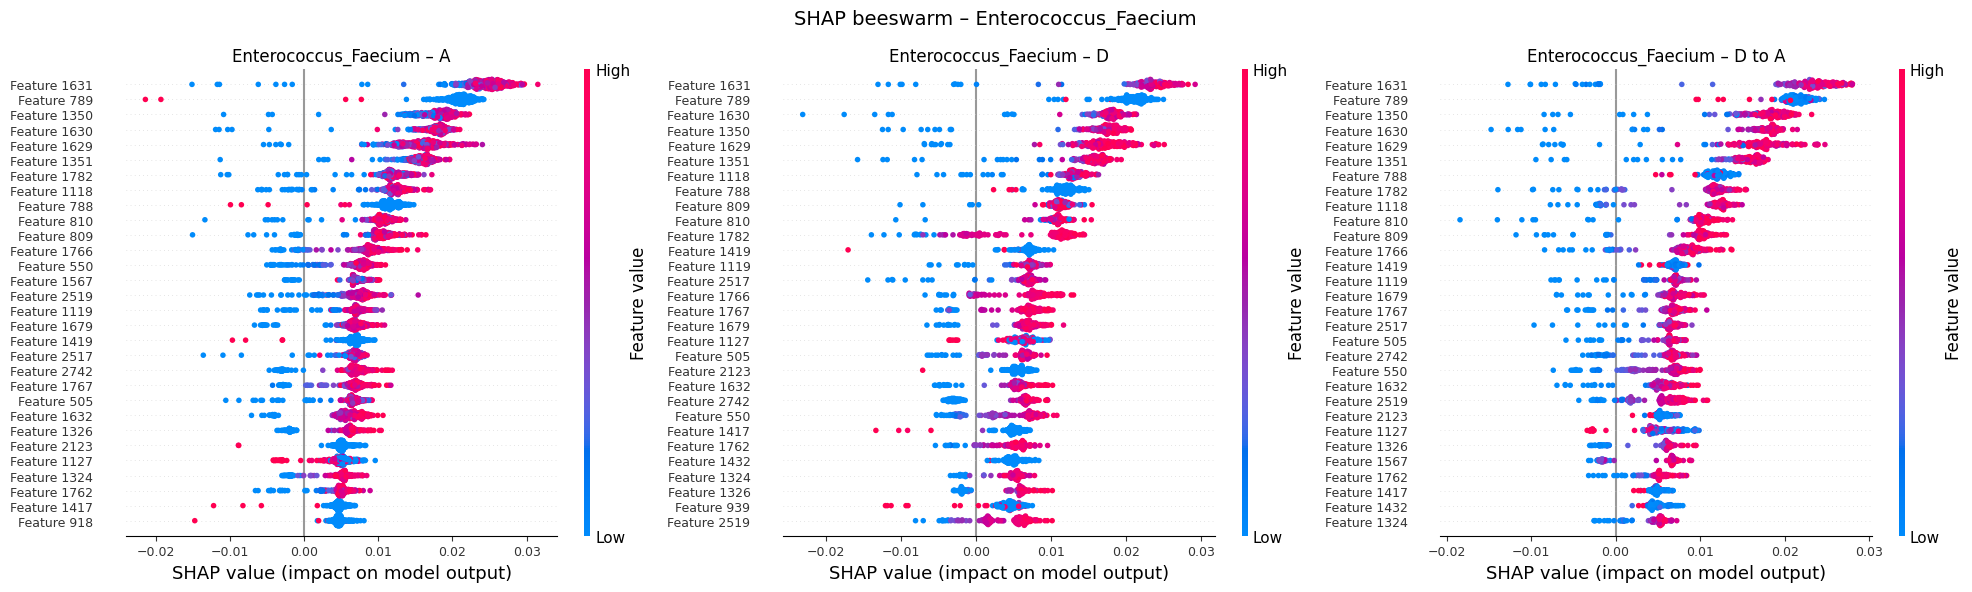

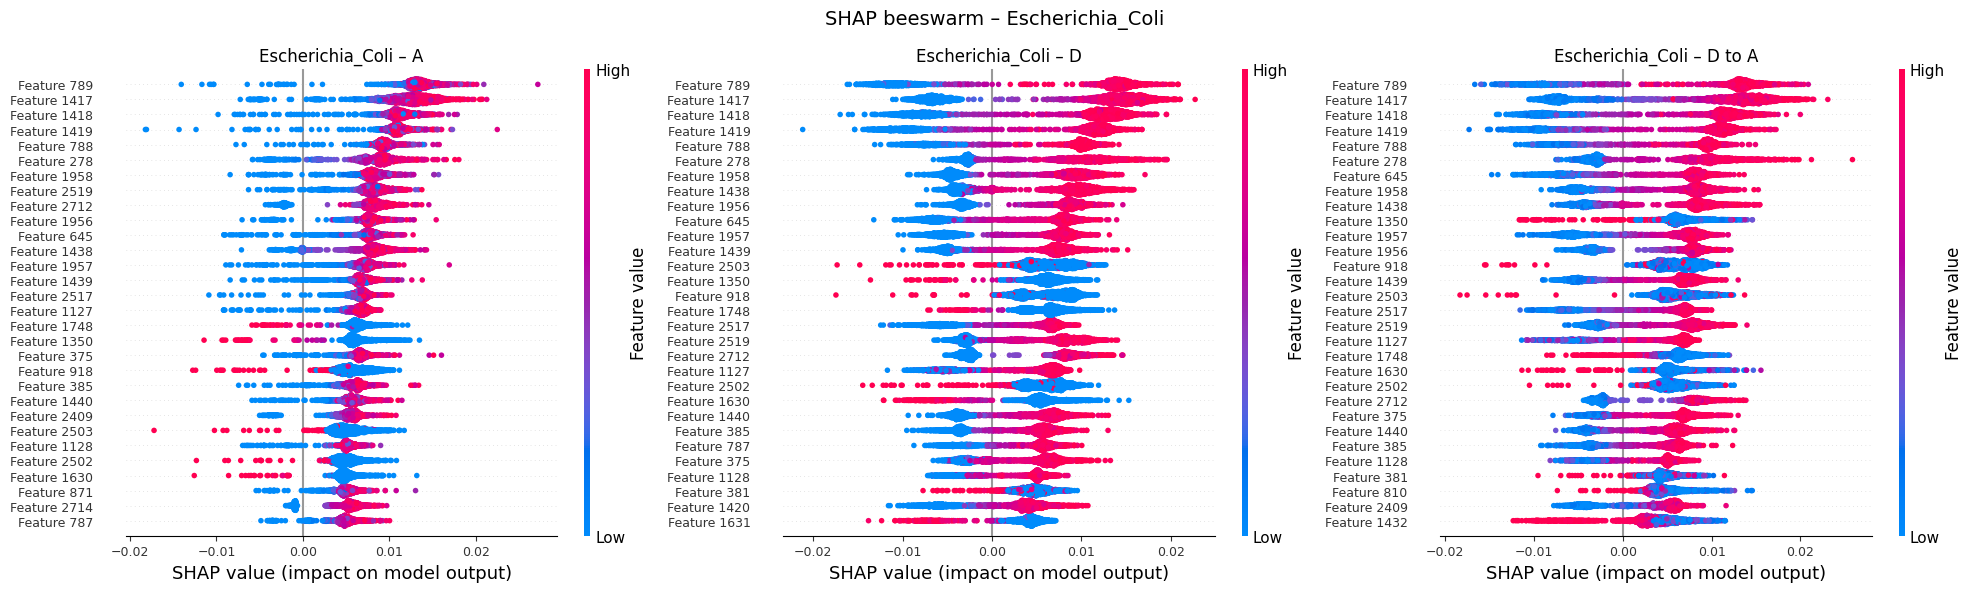

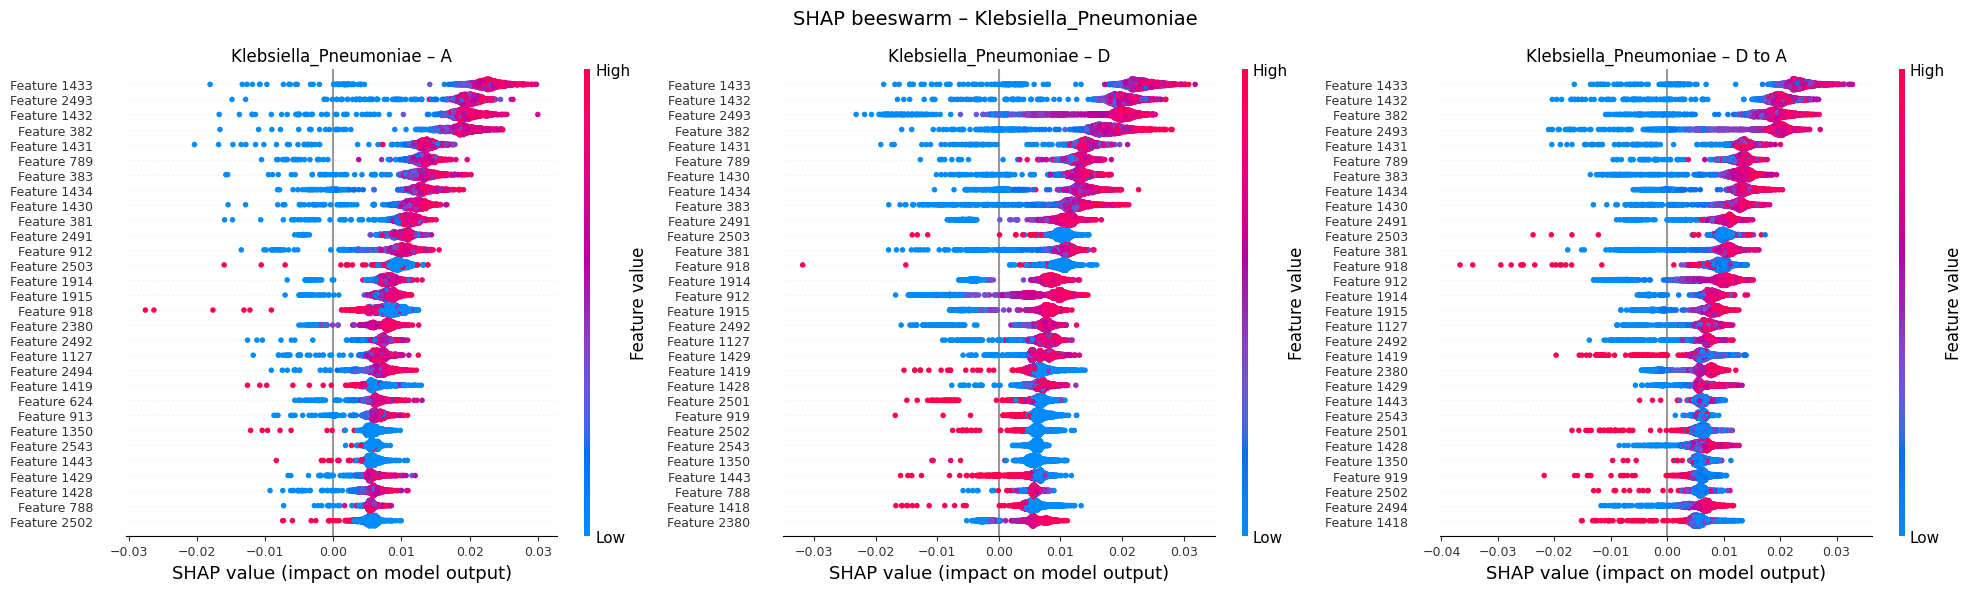

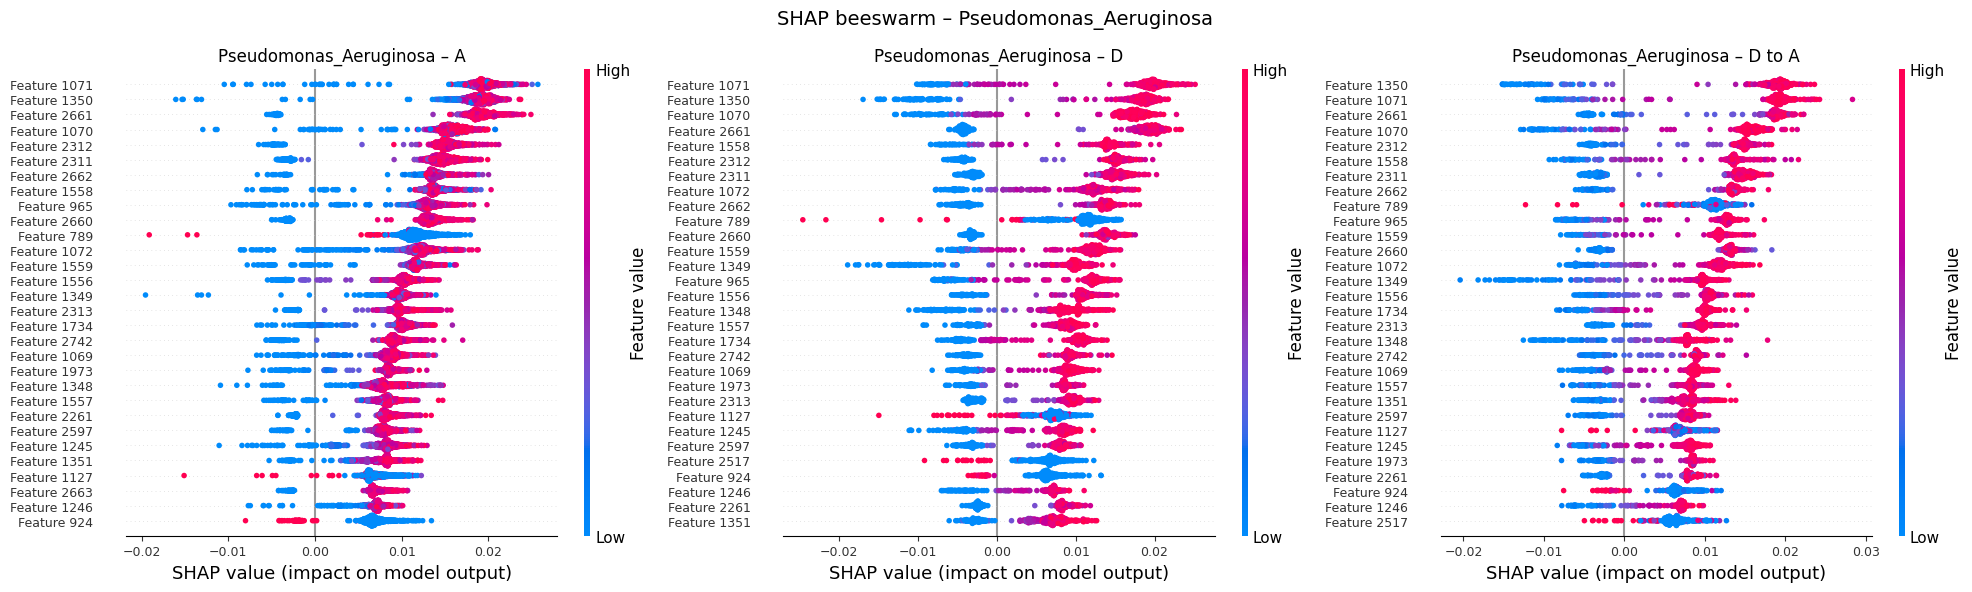

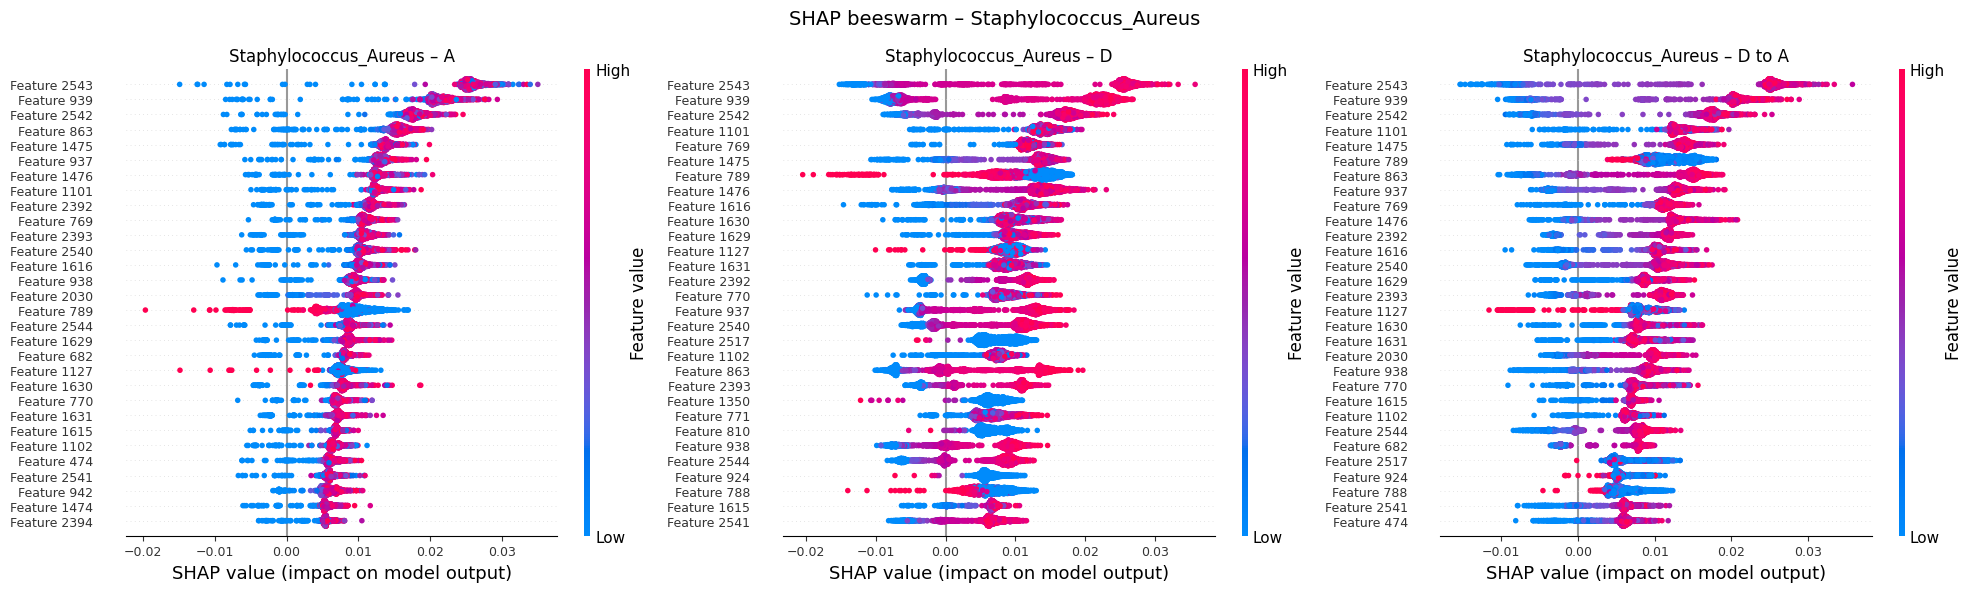

In [75]:
n_species = shap_A.shape[2]
K = 30

for sp in range(n_species):

    class_label = rf_driamsA.classes_[sp]

    idx_A = np.where(y_test == class_label)[0]
    idx_D = np.where(labelD == class_label)[0]

    if len(idx_A) == 0 or len(idx_D) == 0:
        continue

    fig, axes = plt.subplots(
        1, 3,
        figsize=(20, 6)
    )

    plt.sca(axes[0])
    shap.summary_plot(
        shap_A[idx_A, :, sp],
        X_test[idx_A],
        max_display=K,
        show=False,
        plot_size=None
    )
    axes[0].set_title(f"{class_label} – A", fontsize=12)
    axes[0].tick_params(axis="y", labelsize=9)
    axes[0].tick_params(axis="x", labelsize=9)

    plt.sca(axes[1])
    shap.summary_plot(
        shap_D[idx_D, :, sp],
        dataD[idx_D],
        max_display=K,
        show=False,
        plot_size=None
    )
    axes[1].set_title(f"{class_label} – D", fontsize=12)
    axes[1].tick_params(axis="y", labelsize=9)
    axes[1].tick_params(axis="x", labelsize=9)

    plt.sca(axes[2])
    shap.summary_plot(
        shap_D_to_A[idx_D, :, sp],
        X_D_to_A[idx_D],
        max_display=K,
        show=False,
        plot_size=None
    )
    axes[2].set_title(f"{class_label} – D to A", fontsize=12)
    axes[2].tick_params(axis="y", labelsize=9)
    axes[2].tick_params(axis="x", labelsize=9)

    plt.suptitle(f"SHAP beeswarm – {class_label}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [77]:
results_dataframe = pd.DataFrame(results)
results_dataframe

,0,1,2,3,4,5
overlap_A_D,27.000000,26.000000,25.000000,26.000000,27.000000,27.000000
overlap_A_D_to_A,27.000000,28.000000,24.000000,28.000000,27.000000,29.000000
jaccard_A_D,0.818182,0.764706,0.714286,0.764706,0.818182,0.818182
jaccard_A_D_to_A,0.818182,0.875000,0.666667,0.875000,0.818182,0.935484


## Another possible example (MLP on DRIAMS-A)

In [37]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(labelA)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    dataA,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    shuffle=True,
    random_state=42
)

In [39]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,      
    stratify=y_train,
    random_state=42
)

In [40]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

In [43]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)

In [44]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

### Train

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [46]:
from models.baselines.mlp import MLPClassifier_Extended
mlp = MLPClassifier_Extended(X_train.shape[1], len(np.unique(labelA)), epochs=50, lr=1e-4, patience=20)
mlp.trainloop(train_loader, val_loader, device)

Epoch 10/50 | Train Loss: 0.0008168362193839839 | Validation Loss: 0.001989722315920517
Epoch 20/50 | Train Loss: 0.0005692668019385916 | Validation Loss: 0.0022620564045480154
Epoch 30/50 | Train Loss: 0.0004529090390006516 | Validation Loss: 0.002294242235192152
Early stopping at epoch 32


In [47]:
def plot_training_curves(train_loss, val_loss, title="MLP training"):
    epochs = range(1, len(train_loss) + 1)

    plt.figure()
    plt.plot(epochs, train_loss, label="Train loss")
    plt.plot(epochs, val_loss, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

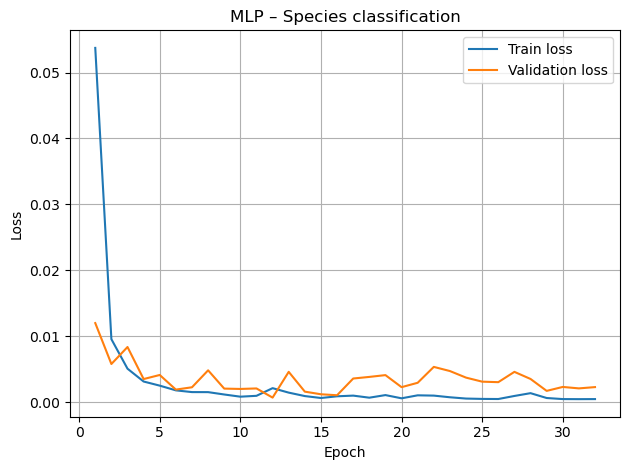

In [48]:
plot_training_curves(
    mlp.loss_during_training,
    mlp.val_loss_during_training,
    title="MLP – Species classification"
)

### Test

In [49]:
def make_test_loader(X, y, batch_size=256):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    dataset = TensorDataset(X_t, y_t)
    return DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [53]:
yD_encoded = le.transform(labelD)
test_loader_A = make_test_loader(X_test, y_test)
test_loader_D = make_test_loader(dataD, yD_encoded)

In [51]:
def metrics_report_mlp(dataloader, model, domain_name, device="cpu", class_names=None):
    model.eval()
    model.to(device)

    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)

            logits = model(x)
            preds = torch.argmax(logits, dim=1)

            y_true.append(y.numpy())
            y_pred.append(preds.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    recall_macro = recall_score(y_true, y_pred, average="macro")

    cm = confusion_matrix(y_true, y_pred)

    specificity = []
    for i in range(len(cm)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity.append(tn / (tn + fp))
    spec_macro = np.mean(specificity)

    return {
        "Domain": domain_name,
        "Labels": np.unique(y_true) if class_names is None else class_names,
        "Balanced_Accuracy": bal_acc,
        "F1_Macro": f1_macro,
        "Recall_Macro": recall_macro,
        "Specificity_Macro": spec_macro,
        "Confusion Matrix": cm
    }


===== Metrics =====
Domain: DRIAMS-A
Balanced Accuracy: 0.9977
F1 Macro: 0.9980
Recall Macro: 0.9977
Specificity Macro: 0.9997



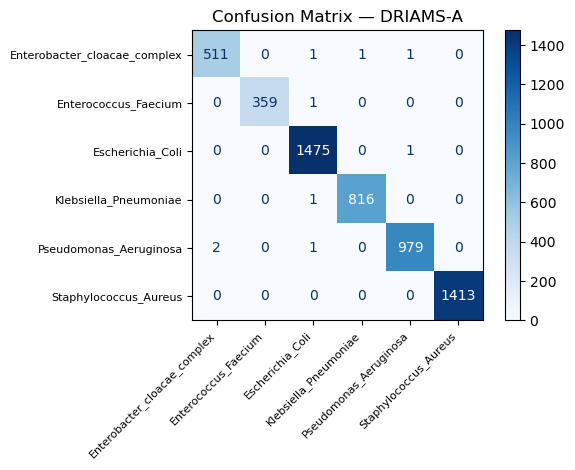


===== Metrics =====
Domain: DRIAMS-D
Balanced Accuracy: 0.9231
F1 Macro: 0.8854
Recall Macro: 0.9231
Specificity Macro: 0.9849



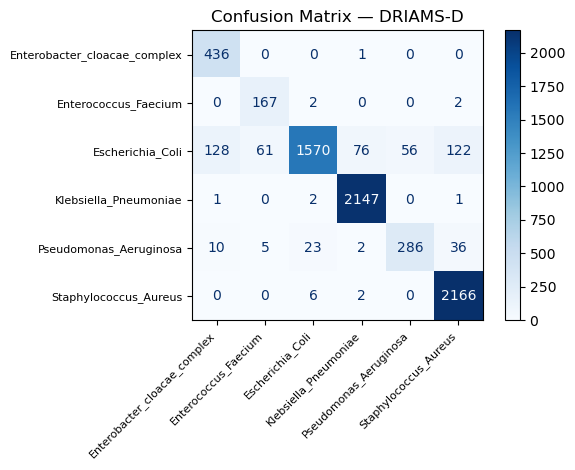

In [54]:
metricsA = metrics_report_mlp(test_loader_A, mlp, "DRIAMS-A", class_names=le.classes_)
metricsD = metrics_report_mlp(test_loader_D, mlp, "DRIAMS-D", class_names=le.classes_)

print_metrics(metricsA)
print_metrics(metricsD)

### Transfer D to A and check performance

In [55]:
X_D_to_A = style_transfer(
    model=vae,
    X=dataD,
    domain_target_id=DOMAIN_MAP["DRIAMS_A"],
    device=device
)

In [56]:
test_loader_D_to_A = make_test_loader(X_D_to_A, yD_encoded)


===== Metrics =====
Domain: DRIAMS-D to A
Balanced Accuracy: 0.9460
F1 Macro: 0.9220
Recall Macro: 0.9460
Specificity Macro: 0.9882



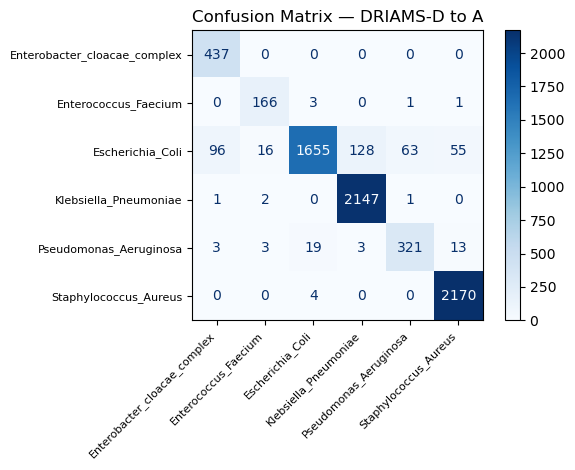

In [57]:
metricsD_to_A = metrics_report_mlp(test_loader_D_to_A, mlp, "DRIAMS-D to A", class_names=le.classes_)
print_metrics(metricsD_to_A)